# 🎯 LỚP 1: PHÂN CỤM & ĐỊNH NGHĨA KHÁCH HÀNG VIP (Ground Truth)

**Mục tiêu:**
1. Phân cụm khách hàng dựa trên RFM + Behavioral (9 chiều).
2. Xác định chính xác nhóm khách hàng VIP.
3. Xuất kết quả làm nhãn (Target) cho Lớp 2.

---

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from database import query_db
import os

# Cấu hình
SAVE_DIR = "d:/PTIT/kì 2 năm 4/Kho dữ liệu và khai phá dữ liệu/BTL/new-datamining"
os.makedirs(SAVE_DIR, exist_ok=True)

## 1. Truy vấn dữ liệu 9 chiều (RFM + Behavioral)

In [6]:
query_full = """
WITH user_rfm AS (
    SELECT
        user_id,
        MAX(created_at)              AS last_purchase_date,
        COUNT(DISTINCT order_id)     AS frequency,
        SUM(sale_price)              AS monetary,
        SUM(sale_price)/COUNT(DISTINCT order_id) AS avg_order_value
    FROM order_items
    WHERE status != 'Cancelled'
    GROUP BY user_id
    HAVING COUNT(DISTINCT order_id) >= 1
),
user_behavioral AS (
    SELECT 
        user_id,
        COUNT(DISTINCT session_id)   AS total_sessions,
        AVG(session_depth)           AS avg_session_depth,
        AVG(products_viewed)         AS avg_products_viewed,
        AVG(has_cart)                AS cart_abandon_rate
    FROM (
        SELECT 
            user_id, session_id,
            MAX(sequence_number) AS session_depth,
            COUNT(CASE WHEN event_type = 'product' THEN 1 END) AS products_viewed,
            MAX(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS has_cart
        FROM events
        WHERE user_id IS NOT NULL
        GROUP BY user_id, session_id
    ) t
    GROUP BY user_id
)
SELECT 
    r.user_id,
    ('2024-01-01'::date - r.last_purchase_date::date) AS recency,
    r.frequency,
    r.monetary,
    r.avg_order_value,
    b.total_sessions,
    b.avg_session_depth,
    b.avg_products_viewed,
    b.cart_abandon_rate,
    CAST(r.frequency AS FLOAT) / NULLIF(b.total_sessions, 0) AS conversion_rate
FROM user_rfm r
INNER JOIN user_behavioral b ON r.user_id = b.user_id
"""

print("⏳ Đang tải dữ liệu khách hàng từ Database...")
df = query_db(query_full)

⏳ Đang tải dữ liệu khách hàng từ Database...


## 2. Phân cụm & Gắn nhãn VIP

In [7]:
if df is not None:
    feature_cols = [
        'recency', 'frequency', 'monetary', 'avg_order_value',
        'total_sessions', 'avg_session_depth', 'avg_products_viewed',
        'cart_abandon_rate', 'conversion_rate'
    ]
    df = df.dropna()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[feature_cols])
    
    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    df['cluster'] = km.fit_predict(X_scaled)
    
    # Tìm cụm có Monetary cao nhất làm VIP
    monetary_rank = df.groupby('cluster')['monetary'].mean().sort_values().index.tolist()
    vip_cluster = monetary_rank[-1]
    
    df['is_vip'] = (df['cluster'] == vip_cluster).astype(int)
    
    # Xuất file nhãn để Lớp 2 sử dụng
    labels_path = os.path.join(SAVE_DIR, "customer_labels.csv")
    df[['user_id', 'is_vip']].to_csv(labels_path, index=False)
    
    print(f"✅ Đã xác định {df['is_vip'].sum():,} khách hàng VIP.")
    print(f"✅ Đã lưu nhãn tại: {labels_path}")

✅ Đã xác định 5,505 khách hàng VIP.
✅ Đã lưu nhãn tại: d:/PTIT/kì 2 năm 4/Kho dữ liệu và khai phá dữ liệu/BTL/new-datamining\customer_labels.csv


## 3. Trực quan hóa kết quả (Radar Chart)

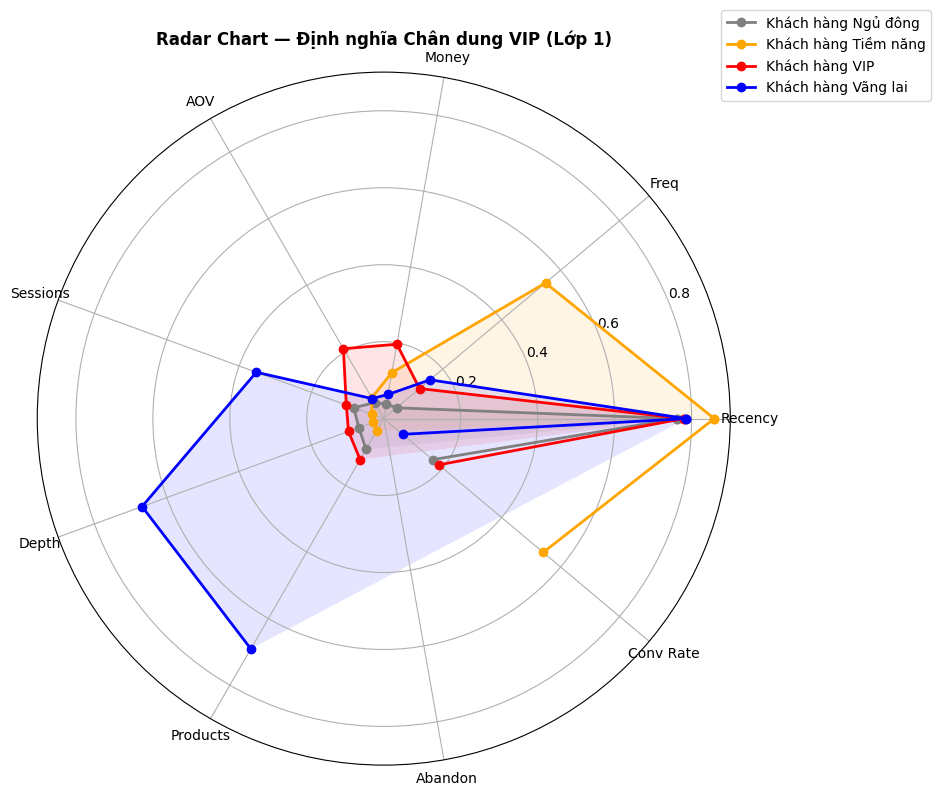

In [8]:
if df is not None:
    # Normalize để vẽ Radar
    df_norm = df.copy()
    for col in feature_cols:
        df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())
    
    # Đảo ngược Recency & Abandon (thấp mới là tốt)
    df_norm['recency'] = 1 - df_norm['recency']
    df_norm['cart_abandon_rate'] = 1 - df_norm['cart_abandon_rate']
    
    name_map = {
        monetary_rank[0]: 'Khách hàng Ngủ đông',
        monetary_rank[1]: 'Khách hàng Vãng lai',
        monetary_rank[2]: 'Khách hàng Tiềm năng',
        monetary_rank[3]: 'Khách hàng VIP'
    }
    df_norm['segment'] = df_norm['cluster'].map(name_map)
    summary = df_norm.groupby('segment')[feature_cols].mean()
    
    categories = ['Recency', 'Freq', 'Money', 'AOV', 'Sessions', 'Depth', 'Products', 'Abandon', 'Conv Rate']
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
    
    plt.figure(figsize=(9, 9))
    ax = plt.subplot(111, polar=True)
    colors = {'Khách hàng VIP': 'red', 'Khách hàng Tiềm năng': 'orange', 'Khách hàng Vãng lai': 'blue', 'Khách hàng Ngủ đông': 'gray'}
    
    for seg in summary.index:
        values = summary.loc[seg].tolist() + [summary.loc[seg].iloc[0]]
        ax.plot(angles, values, 'o-', linewidth=2, label=seg, color=colors[seg])
        ax.fill(angles, values, alpha=0.1, color=colors[seg])
        
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    plt.title('Radar Chart — Định nghĩa Chân dung VIP (Lớp 1)', fontweight='bold', pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()